In [3]:
import xarray as xr
import glob
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
    
plt.rcParams.update({"font.size": 16})

In [4]:
# choose latest 24 hours of goflow files

file_path = '/home/mduplessis/share/EUMETSAT/processed_goflow_inputs/5E-25E_44S-33S'

flist = sorted(glob.glob(f'{file_path}/*.nc'))[-20:]

ds = xr.open_mfdataset(flist, combine='nested', concat_dim='time', parallel=True)
ds = ds.sortby('time')
ds = ds.isel(time=~ds.indexes['time'].duplicated())

ds['BT'] = ds['BT'] - 273.15  # Convert from Kelvin to Celsius

ds['BT_masked'] = ds['BT'].where(ds['mask'] == 1) # Apply mask to BT

In [5]:
import os
import pandas as pd

start_time = pd.to_datetime(ds.time.min().values)
end_time = pd.to_datetime(ds.time.max().values)

start_date = start_time.strftime('%Y%m%d')
end_date = end_time.strftime('%Y%m%d')

output_dir = '/home/mduplessis/share/EUMETSAT/goflow_daily_means/'
output_filename = f'BT_masked_Meteosat_{start_date}_{end_date}.nc'
output_path = os.path.join(output_dir, output_filename)
os.makedirs(output_dir, exist_ok=True)

bt_to_save = ds['BT_masked'].copy()
bt_to_save.attrs.update({
    'long_name': 'Masked brightness temperature',
    'units': 'C',
    'start_time': start_time.isoformat(),
    'end_time': end_time.isoformat(),
})

bt_to_save.name = 'BT_masked'
bt_to_save = bt_to_save.max(dim='time')
bt_to_save.to_netcdf(output_path)

print(f'Saved {bt_to_save.name} to {output_path}')
print(f"time_coverage_start: {bt_to_save.attrs['start_time']}")
print(f"time_coverage_end: {bt_to_save.attrs['end_time']}")

Saved BT_masked to /home/mduplessis/share/EUMETSAT/goflow_daily_means/BT_masked_Meteosat_20260703_20260704.nc
time_coverage_start: 2026-07-03T11:10:00
time_coverage_end: 2026-07-04T12:00:00


In [6]:
bt_to_save

<xarray.DataArray 'BT_masked' (lat: 550, lon: 1000)> Size: 2MB
dask.array<_nanmax_skip-aggregate, shape=(550, 1000), dtype=float32, chunksize=(275, 500), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB -43.99 -43.97 -43.95 ... -33.05 -33.03 -33.01
  * lon      (lon) float64 8kB 5.01 5.03 5.05 5.07 ... 24.93 24.95 24.97 24.99
Attributes: (12/21)
    ancillary_variables:                   ir_105_pixel_quality
    calibration:                           brightness_temperature
    comment:                               Only for IR channels. Set to _Fill...
    end_time:                              2026-07-04T12:00:00
    file_type:                             fci_l1c_hrfi
    grid_mapping:                          geo_area
    ...                                    ...
    time_parameters:                       {"nominal_start_time": "2026-07-03...
    units:                                 C
    valid_cold_range:                      [   0 4095]
    wavelength:                            10.5 µm (9.8-11.2 µm)
    long_name:                             Masked brightness temperature
    source:                                FCI L1C RRAD FDHSI, channel ir_105...

In [7]:
print(ds.time[0])
print(ds.time[-1])

<xarray.DataArray 'time' ()> Size: 8B
array('2026-07-03T11:10:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2026-07-03T11:10:00
Attributes:
    standard_name:  time
    long_name:      time
<xarray.DataArray 'time' ()> Size: 8B
array('2026-07-04T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2026-07-04T12:00:00
Attributes:
    standard_name:  time
    long_name:      time


In [8]:
import requests
import pandas as pd
import numpy as np

DEFAULT_EDDY_BASE = "https://thredds-x.ipsl.fr/thredds/fileServer/WHIRLS/PRODUCTS/TOEDDIES"

def _to_float_or_none(value):
    try:
        if value is None:
            return None
        return float(value)
    except (TypeError, ValueError):
        return None

def _as_feature_list(gj):
    if not isinstance(gj, dict):
        return []
    feats = gj.get("features", [])
    return feats if isinstance(feats, list) else []

def _parse_polygon_features(gj):
    out = {}
    for feat in _as_feature_list(gj):
        props = feat.get("properties", {}) or {}
        geom = feat.get("geometry", {}) or {}
        if geom.get("type") != "Polygon":
            continue

        idx = props.get("eddy_index")
        if idx is None:
            continue

        coords = geom.get("coordinates", [])
        if not coords:
            continue

        ring = np.asarray(coords[0])
        if ring.size == 0:
            continue

        out[int(idx)] = {
            "lon": ring[:, 0],
            "lat": ring[:, 1],
            "properties": props,
        }
    return out

def _parse_center_features(gj):
    out = {}
    for feat in _as_feature_list(gj):
        props = feat.get("properties", {}) or {}
        geom = feat.get("geometry", {}) or {}
        if geom.get("type") != "Point":
            continue

        idx = props.get("eddy_index")
        coords = geom.get("coordinates", [])
        if idx is None or len(coords) < 2:
            continue

        out[int(idx)] = {
            "center_lon": float(coords[0]),
            "center_lat": float(coords[1]),
            "speed": _to_float_or_none(props.get("speed")),
            "properties": props,
        }
    return out

def _fetch_geojson(session, url):
    r = session.get(url, timeout=60)
    r.raise_for_status()
    payload = r.json()
    return payload if isinstance(payload, dict) else {"features": []}

def _load_eddy_type_for_date(session, date_str, eddy_type, base_url):
    outcontour_url = f"{base_url}/{date_str}_{eddy_type}_outcontour.geojson"
    maxspeed_url = f"{base_url}/{date_str}_{eddy_type}_maxspeed.geojson"
    centers_url = f"{base_url}/{date_str}_{eddy_type}_centers.geojson"

    outcontours = _parse_polygon_features(_fetch_geojson(session, outcontour_url))
    maxspeeds = _parse_polygon_features(_fetch_geojson(session, maxspeed_url))
    centers = _parse_center_features(_fetch_geojson(session, centers_url))

    all_idx = sorted(set(outcontours) | set(maxspeeds) | set(centers))
    eddies = []
    for idx in all_idx:
        contour = outcontours.get(idx, {})
        maxc = maxspeeds.get(idx, {})
        center = centers.get(idx, {})

        eddies.append({
            "eddy_index": idx,
            "outcontour_lon": contour.get("lon"),
            "outcontour_lat": contour.get("lat"),
            "maxspeed_lon": maxc.get("lon"),
            "maxspeed_lat": maxc.get("lat"),
            "center_lon": center.get("center_lon"),
            "center_lat": center.get("center_lat"),
            "maxspeed": center.get("speed"),
            "outcontour_properties": contour.get("properties", {}),
            "maxspeed_properties": maxc.get("properties", {}),
            "center_properties": center.get("properties", {}),
        })
    return eddies

def load_eddy_data(dates, base_url=DEFAULT_EDDY_BASE):
    session = requests.Session()
    session.headers.update({"User-Agent": "python-requests"})

    eddy_data = {}
    for d in pd.to_datetime(dates):
        date_str = d.strftime("%Y-%m-%d")
        day_data = {"cyclones": [], "anticyclones": []}

        try:
            day_data["cyclones"] = _load_eddy_type_for_date(session, date_str, "cyclones", base_url)
        except requests.HTTPError:
            print(f"Missing cyclone files for {date_str}")
        except Exception as exc:
            print(f"Error reading cyclone files for {date_str}: {exc}")

        try:
            day_data["anticyclones"] = _load_eddy_type_for_date(session, date_str, "anticyclones", base_url)
        except requests.HTTPError:
            print(f"Missing anticyclone files for {date_str}")
        except Exception as exc:
            print(f"Error reading anticyclone files for {date_str}: {exc}")

        eddy_data[date_str] = day_data

    return eddy_data

frame_dates = pd.to_datetime(ds.time.values).normalize().unique()
eddy_data = load_eddy_data(frame_dates, base_url=DEFAULT_EDDY_BASE)

In [9]:
def draw_eddy_lines(frame_date):
	artists = []
	cyclones = eddy_data.get(frame_date, {}).get("cyclones", [])
	anticyclones = eddy_data.get(frame_date, {}).get("anticyclones", [])
	for eddy in cyclones:
		if eddy.get("outcontour_lon") is not None and eddy.get("outcontour_lat") is not None:
			line_out, = ax.plot(
				eddy["outcontour_lon"],
				eddy["outcontour_lat"],
				color="tab:blue",
				linestyle="-",
				linewidth=1.2,
				alpha=0.8,
				transform=ccrs.PlateCarree(),
				zorder=12,
			)
			artists.append(line_out)
		if eddy.get("maxspeed_lon") is not None and eddy.get("maxspeed_lat") is not None:
			line_max, = ax.plot(
				eddy["maxspeed_lon"],
				eddy["maxspeed_lat"],
				color="tab:blue",
				linestyle="--",
				linewidth=2.8,
				transform=ccrs.PlateCarree(),
				zorder=13,
			)
			artists.append(line_max)
		if eddy.get("center_lon") is not None and eddy.get("center_lat") is not None:
			dot = ax.scatter(
				eddy["center_lon"],
				eddy["center_lat"],
				color="tab:blue",
				s=25,
				marker="o",
				transform=ccrs.PlateCarree(),
				zorder=14,
			)
			artists.append(dot)
	for eddy in anticyclones:
		if eddy.get("outcontour_lon") is not None and eddy.get("outcontour_lat") is not None:
			line_out, = ax.plot(
				eddy["outcontour_lon"],
				eddy["outcontour_lat"],
				color="tab:red",
				linestyle="-",
				linewidth=1.2,
				alpha=0.8,
				transform=ccrs.PlateCarree(),
				zorder=12,
			)
			artists.append(line_out)
		if eddy.get("maxspeed_lon") is not None and eddy.get("maxspeed_lat") is not None:
			line_max, = ax.plot(
				eddy["maxspeed_lon"],
				eddy["maxspeed_lat"],
				color="tab:red",
				linestyle="--",
				linewidth=2.8,
				transform=ccrs.PlateCarree(),
				zorder=13,
			)
			artists.append(line_max)
		if eddy.get("center_lon") is not None and eddy.get("center_lat") is not None:
			dot = ax.scatter(
				eddy["center_lon"],
				eddy["center_lat"],
				color="tab:red",
				s=25,
				marker="o",
				transform=ccrs.PlateCarree(),
				zorder=14,
			)
			artists.append(dot)
	return artists

In [10]:
import gsw

ship_lat, ship_lon = -38.1555, 11.9678

xspar_lat, xspar_lon = -37.424723, 11.549094

# gsw.distance([ship_lon, deploy_lon], [ship_lat, deploy_lat])

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3643882/2210821698.py:12: SyntaxWarning: invalid escape sequence '\c'
  cbar_kwargs={"label": "IR brightness temperature [$^{^\circ}$C]", "aspect": 30, "pad": 0.02},
/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-pac

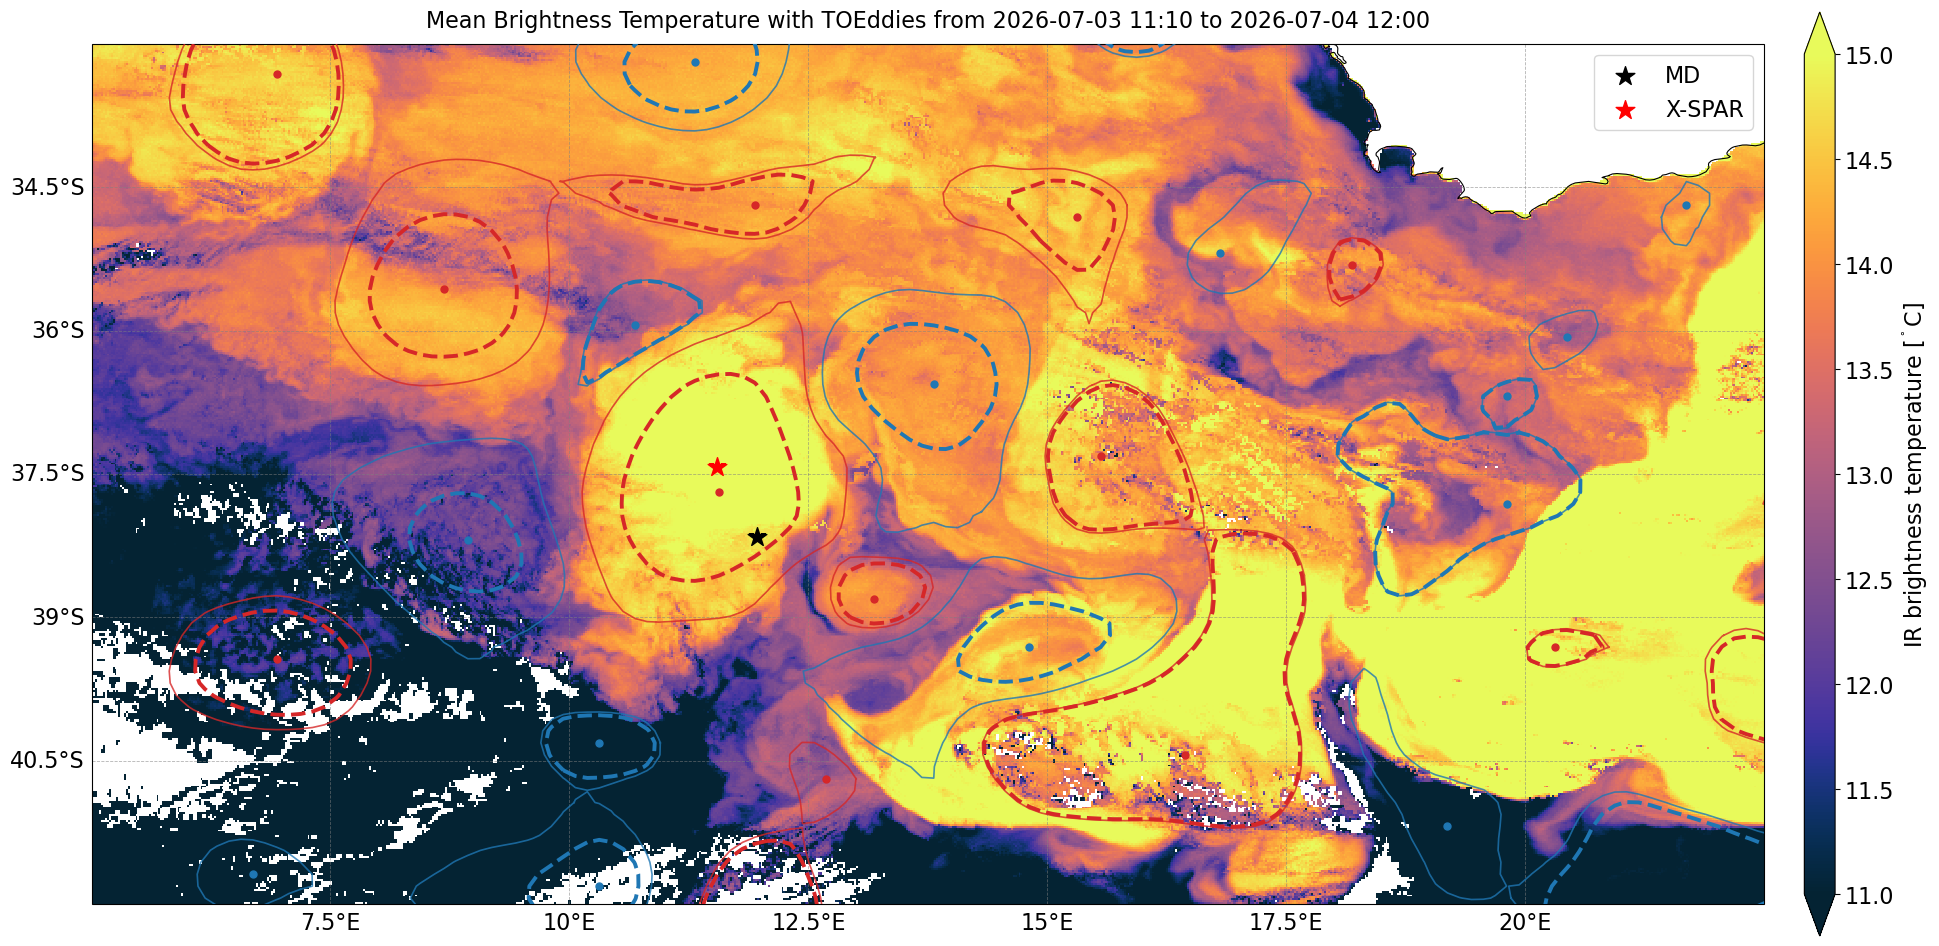

In [11]:
fig, ax = plt.subplots(
    figsize=(26, 12),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

ds.BT_masked.max(dim="time").plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmo.thermal,
    vmin=11,
    vmax=15,
    cbar_kwargs={"label": "IR brightness temperature [$^{^\circ}$C]", "aspect": 30, "pad": 0.02},
)  

ax.set_extent(
    [float(ds.lon.min()), float(ds.lon.max()), float(ds.lat.min()), float(ds.lat.max())],
    crs=ccrs.PlateCarree(),
)
ax.coastlines(resolution="10m", linewidth=0.8, color="black")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.6,
    color="gray",
    alpha=0.6,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

eddy_lines = draw_eddy_lines(np.datetime_as_string(ds.time.values[-1], unit="D"))

start_time = pd.to_datetime(ds.time.values[0]).strftime("%Y-%m-%d %H:%M")
end_time = pd.to_datetime(ds.time.values[-1]).strftime("%Y-%m-%d %H:%M")
ax.set_title(
    f"Mean Brightness Temperature with TOEddies from {start_time} to {end_time}",
    fontsize=16,
    pad=12,
)

ax.set_extent([5, 22.5, -42, -33], crs=ccrs.PlateCarree())

# ship position
ax.scatter(ship_lon, ship_lat, color="black", s=200, marker="*", transform=ccrs.PlateCarree(), zorder=14, label='MD')
 
# xspar
ax.scatter(xspar_lon, xspar_lat, color="red", s=200, marker="*", transform=ccrs.PlateCarree(), zorder=14, label='X-SPAR')

ax.legend()

# ax.scatter(12, -37.34, color="black", s=300, marker="*", transform=ccrs.PlateCarree(), zorder=14)

# New possible waypoint
# ax.scatter(11.65, -37.4, color="red", s=300, marker="*", transform=ccrs.PlateCarree(), zorder=14)


<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3643882/2660689802.py:21: SyntaxWarning: invalid escape sequence '\c'
  cbar_kwargs={"label": "IR brightness temperature gradient [$^{^\circ}$C / km]", "aspect": 30, "pad": 0.02},


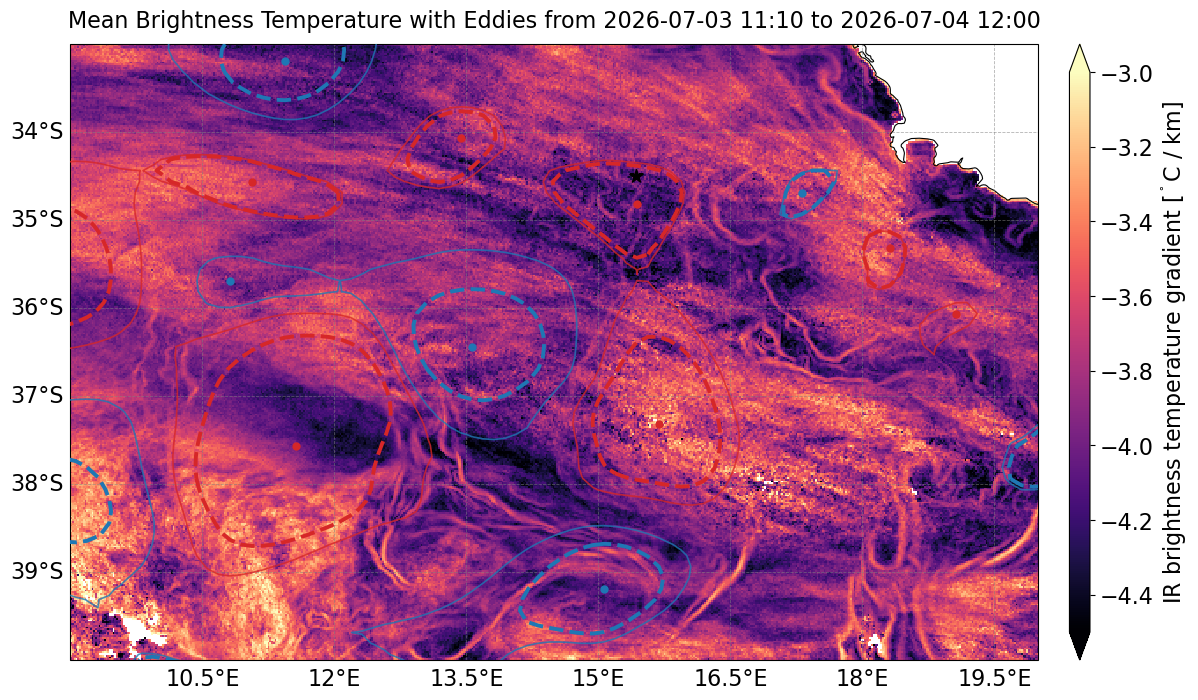

In [12]:
fig, ax = plt.subplots(
    figsize=(20, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# ds.BT_masked.max(dim="time").plot(
#     ax=ax,
#     transform=ccrs.PlateCarree(),
#     cmap=cmo.thermal,
#     vmin=10,
#     vmax=15,
#     cbar_kwargs={"label": "IR brightness temperature [$^{^\circ}$C]", "aspect": 30, "pad": 0.02},
# )  

ds.loggrad_T_masked.mean(dim="time").plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='magma',
    vmin=-4.5,
    vmax=-3.0,
    cbar_kwargs={"label": "IR brightness temperature gradient [$^{^\circ}$C / km]", "aspect": 30, "pad": 0.02},
)

ax.set_extent(
    [float(ds.lon.min()), float(ds.lon.max()), float(ds.lat.min()), float(ds.lat.max())],
    crs=ccrs.PlateCarree(),
)
ax.coastlines(resolution="10m", linewidth=0.8, color="black")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.6,
    color="gray",
    alpha=0.6,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

eddy_lines = draw_eddy_lines(np.datetime_as_string(ds.time.values[0], unit="D"))

start_time = pd.to_datetime(ds.time.values[0]).strftime("%Y-%m-%d %H:%M")
end_time = pd.to_datetime(ds.time.values[-1]).strftime("%Y-%m-%d %H:%M")
ax.set_title(
    f"Mean Brightness Temperature with Eddies from {start_time} to {end_time}",
    fontsize=16,
    pad=12,
)

ax.set_extent([9, 20, -40, -33], crs=ccrs.PlateCarree())

ax.scatter(15.4270, -34.5001, color="black", s=100, marker="*", transform=ccrs.PlateCarree(), zorder=14)